In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl

In [2]:
import mesa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from abm.model import SocialGPModel
from abm.rewards import make_mexican_hat_reward
from abm.utils import plot_reward_grid, plot_most_common_choice_trajectory
from matplotlib.animation import FuncAnimation
sns.set_theme(style="whitegrid")

# Single agent simulations
This notebook shows simulations done to establish the behavior of single agents in Mexican hat environments

## 1. Asocial individuals, human-like parameters

In [56]:
rng = np.random.default_rng(42)

grid_size = 50
reward_params = {
    'frequency': 2.5,
    'center': (grid_size // 4, grid_size // 4),
    'correlation': 1
}
params = {
    "n": [1],
    "grid_size": grid_size,
    "rng": rng,
    "beta": 0.3,
    "length_scale": grid_size * 1.5 / (2*np.pi * reward_params['frequency']), #* 0.55
    "tau": 0.03,
    "alpha": 0,
    "reward_env_type": 'dog',
    "reward_env_params": [reward_params]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params,
    max_steps=25,
    display_progress=True,
    data_collection_period=1,
    number_processes=None
)

  0%|          | 0/1 [00:00<?, ?it/s]

### A. Plot mean across many iterations

In [ ]:
df_batch = pd.DataFrame(batch_results)

# 1. Plot most common choice trajectory
reward = make_mexican_hat_reward(grid_size, 
                                 frequency=reward_params['frequency'], 
                                 center=reward_params['center'])
plot_most_common_choice_trajectory(df_batch, reward, title='')

# 2. Plot mean reward and local/global max probabilities
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Avg reward with SE
axes[0].plot(df_batch['Step'], df_batch['mean_reward'], label='Mean Reward')
axes[0].fill_between(df_batch['Step'], df_batch['mean_reward'] - df_batch['se_reward'], df_batch['mean_reward'] + df_batch['se_reward'], alpha=0.3)
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()
# Prob near peak
axes[1].plot(df_batch['Step'], df_batch['prob_near_peak'], label='Prob global peak', color='orange')
axes[1].plot(df_batch['Step'], df_batch['prob_local_max'], label='Prob local max', color='green')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()

### B. Plot Individual trajectories

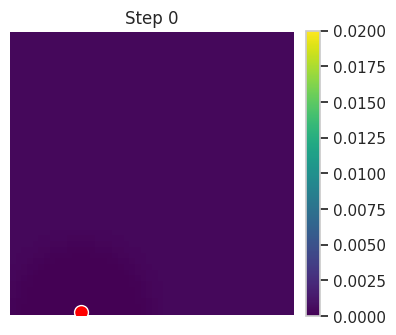

In [64]:
df_batch = pd.DataFrame(batch_results)

heatmaps = df_batch['policy'].to_numpy()  # shape (60,), each element is a 2D array
fig, ax = plt.subplots(figsize=(4, 4))

vmin = min(h.min() for h in heatmaps)
vmax = min(max(h.max() for h in heatmaps), 0.02)

im = ax.imshow(
    heatmaps[1].T, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax
)
ax.scatter(df_batch.loc[0, 'choice'][0], df_batch.loc[0, 'choice'][1], color='red', s=100, edgecolor='white')
ax.axis('off')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def update(frame):
    ax.clear()  # Clear previous scatter points
    # im.set_array(heatmaps[frame+1])  # Update the data
    im = ax.imshow(
        heatmaps[frame+1].T, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax
    )
    ax.scatter(df_batch.loc[frame, 'choice'][0], df_batch.loc[frame, 'choice'][1], color='red', s=100, edgecolor='white')
    ax.set_title(f'Step {frame}')
    ax.axis('off')
    return im,

ani = FuncAnimation(fig, update, frames=len(heatmaps)-1, repeat=False)
ani.save('policy_evolution.gif', writer='pillow', fps=1)

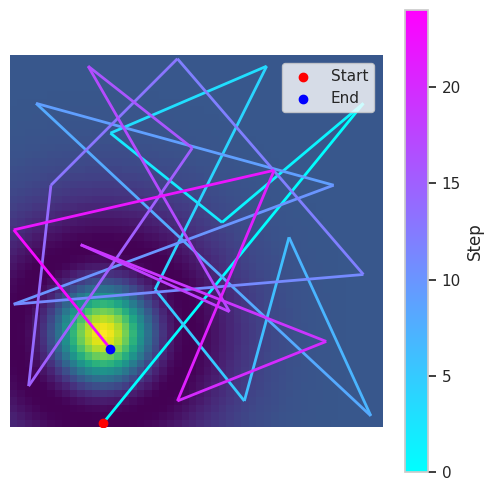

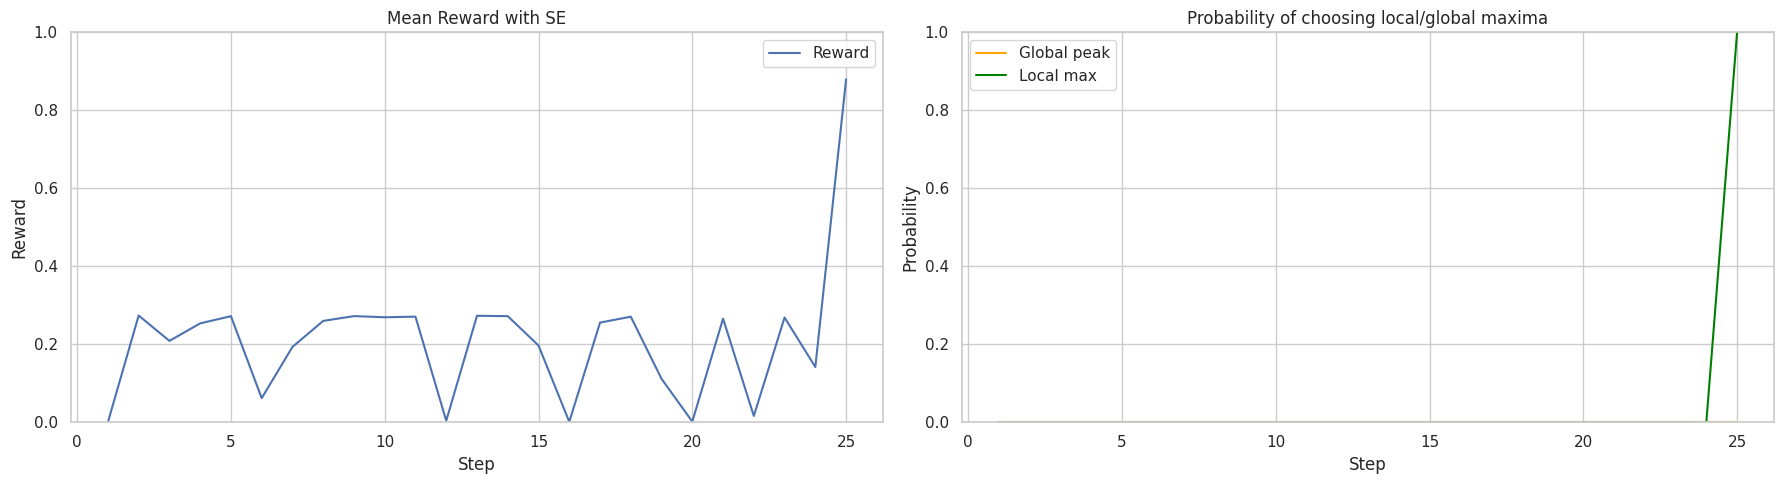

In [60]:
# 1. Plot most common choice trajectory
reward = make_mexican_hat_reward(grid_size, 
                                 frequency=reward_params['frequency'], 
                                 center=reward_params['center'])
plot_most_common_choice_trajectory(df_batch, reward, title='', choice_col='choice')

# 2. Plot mean reward and local/global max probabilities
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Avg reward with SE
axes[0].plot(df_batch['Step'], df_batch['reward'], label='Reward')
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()
# Prob near peak
axes[1].plot(df_batch['Step'], df_batch['near_peak'], label='Global peak', color='orange')
axes[1].plot(df_batch['Step'], df_batch['local_max'], label='Local max', color='green')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()